# Data 606 - Assignment P2

Name : Arunbh Yashaswi

UID : 121304537

## Mounting the Google Drive `drive`



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imported Libraries

In [3]:
import itertools
import logging
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity
# from joblib import Parallel, delayed
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
from joblib import Parallel, delayed

## Constants for the notebook

defined TRAIN_RATIO and K for testing original experiment underneath

In [5]:
#Contsants

RANDOM_SEED = 42
TRAIN_RATIO = 0.75
K = 15

## Loading Data

In [6]:

def load_and_merge(ratings_path: str,
                   users_path: str,
                   books_path: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return ratings, users, books DataFrames (clean types only)."""
    ratings = pd.read_csv(
        ratings_path,
        usecols=["User-ID", "ISBN", "Book-Rating"],
        dtype={"User-ID": "int32", "ISBN": "string", "Book-Rating": "int8"},
    )
    users = pd.read_csv(users_path, dtype={"User-ID": "int32"})
    books = pd.read_csv(books_path, dtype={"ISBN": "string", "Year-Of-Publication": "string"})
    return ratings, users, books


In [7]:
ratings_path = "/content/drive/MyDrive/UMD/DATA606/p2/data/Ratings.csv"
books_path   = "/content/drive/MyDrive/UMD/DATA606/p2/data/Books.csv"
users_path   = "/content/drive/MyDrive/UMD/DATA606/p2/data/Users.csv"

In [8]:
ratings_df, users_df, books_df = load_and_merge(ratings_path, users_path, books_path)
ratings_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [9]:
ratings_df.shape

(1149780, 3)

## Data Pre-Processing

Data Cleaning in basic_cleanup



*   Rating and Year Validation: Removes ratings outside 1-10 and books published after 2025, ensuring data relevance.
*   Duplicate Handling: Averages duplicate ratings by the same user for the same book, keeping one entry with the mean rating.
*   Data Integrity: Removes ratings for books missing in the books DataFrame, ensuring consistency.

In [10]:
def basic_cleanup(ratings: pd.DataFrame,
                  users: pd.DataFrame,
                  books: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Keep sensible rows, coerce ranges."""
    # rating 0 means "unrated" in rated so dropping it. And Based on question setting max limit to 10
    ratings = ratings.loc[(ratings["Book-Rating"] >= 1) & (ratings["Book-Rating"] <= 10)].copy()


    #Calculate the mean rating for duplicate pairs and Update the 'Book-Rating' column with the mean rating
    mean_ratings = ratings.groupby(['ISBN', 'User-ID'])['Book-Rating'].mean().reset_index()
    ratings = ratings.drop_duplicates(subset=['ISBN', 'User-ID'], keep='first')
    ratings = ratings.merge(mean_ratings, on=['ISBN', 'User-ID'], suffixes=('', '_mean'))
    ratings['Book-Rating'] = ratings['Book-Rating_mean']
    ratings = ratings.drop(columns=['Book-Rating_mean'])

    #  Trimming based on Year-Of-Publication
    yop = pd.to_numeric(books["Year-Of-Publication"], errors="coerce")
    valid = (yop <= 2025)          # this is a nullable-bool Series
    books["Year-Of-Publication"] = yop.where(valid)   #  keeps good rows, NaN elsewhere

    # Inner join to eliminate orphan ids
    ratings = ratings.merge(books[["ISBN"]],   on="ISBN",    how="inner")

    return ratings.reset_index(drop=True), users, books

In [11]:
cleaned_rating,_,_  = basic_cleanup(ratings_df, users_df, books_df)

In [12]:
cleaned_rating

,User-ID,ISBN,Book-Rating
0,276726,0155061224,5.0
1,276729,052165615X,3.0
2,276729,0521795028,6.0
3,276744,038550120X,7.0
4,276747,0060517794,9.0
...,...,...,...
383837,276704,0743211383,7.0
383838,276704,0806917695,5.0
383839,276704,1563526298,9.0
383840,276709,0515107662,10.0


## Trimming
Trimming out books which are not read that much and user who don't read as much To ensure there activeness among the users and items




In [13]:
def frequency_filter(df: pd.DataFrame,
                     min_item_r: int = 1,
                     min_user_r: int = 2) -> pd.DataFrame:
    """Drop books/users below activity thresholds.  Returns new DataFrame."""
    df = df.groupby("ISBN").filter(lambda x: len(x) >= min_item_r)
    df = df.groupby("User-ID").filter(lambda x: len(x) >= min_user_r)
    return df.reset_index(drop=True)

filtered_rating = frequency_filter(cleaned_rating)

In [14]:
filtered_rating

,User-ID,ISBN,Book-Rating
0,276729,052165615X,3.0
1,276729,0521795028,6.0
2,276747,0060517794,9.0
3,276747,0671537458,9.0
4,276747,0679776818,8.0
...,...,...,...
344614,276704,0345386108,6.0
344615,276704,0380796155,5.0
344616,276704,0743211383,7.0
344617,276704,0806917695,5.0


## Build sparse matrix

Using Sparse Matrix for following:

*  Memory Efficiency: Sparse matrices store only non-zero values, significantly reducing memory usage compared to DataFrames, especially for sparse data like user-item ratings where most entries are zero.
*  Computational Efficiency: Algorithms for recommendation tasks (e.g., similarity calculations) are optimized for sparse matrices, resulting in faster computations by only processing non-zero values.
*  Data Sparsity: User-item interaction data is inherently sparse; most users rate a small fraction of items. Sparse matrices are designed to efficiently represent this sparsity.
*  Algorithm Compatibility: Many recommendation algorithms require sparse matrices as input, aligning with common practices in this domain.

In [15]:
def build_matrix(df: pd.DataFrame,
                 user_map: Dict[int, int],
                 item_map: Dict[str, int]) -> sparse.csr_matrix:
    rows = df["User-ID"].map(user_map).to_numpy()
    cols = df["ISBN"].map(item_map).to_numpy()
    data = df["Book-Rating"].to_numpy(dtype=np.float32)
    return sparse.csr_matrix(
        (data, (rows, cols)),
        shape=(len(user_map), len(item_map)),
        dtype=np.float32,
    )

df = filtered_rating.copy()
rng = np.random.default_rng(RANDOM_SEED)
mask = rng.random(len(df)) < TRAIN_RATIO
train_df, test_df = df[mask].copy(), df[~mask].copy()

user_map = {uid: idx for idx, uid in enumerate(df["User-ID"].unique())}
item_map = {isbn: idx for idx, isbn in enumerate(df["ISBN"].unique())}
csr_rating_train = build_matrix(train_df, user_map, item_map)
csr_rating_train

<28868x141474 sparse matrix of type '<class 'numpy.float32'>'
	with 258469 stored elements in Compressed Sparse Row format>

## Item mean de-trend for similarity only

Computes item-centered ratings by subtracting each item’s mean rating from its nonzero ratings, ensuring unbiased similarity calculations.

In [16]:
def demean_by_item(R: sparse.csr_matrix
                   ) -> Tuple[sparse.csr_matrix, np.ndarray]:
    """Return demeaned copy and item means μ_j."""
    # mean over non-zero entries
    nz_mask = R != 0
    item_sum = np.asarray(R.sum(axis=0)).ravel()
    item_cnt = nz_mask.sum(axis=0).A1.clip(min=1)  # avoid zero
    item_mean = item_sum / item_cnt
    R_dm = R.copy().astype(np.float32)
    r, c = R_dm.nonzero()
    R_dm.data -= item_mean[c]
    return R_dm, item_mean.astype(np.float32)

# global_mean = train_df["Book-Rating"].mean()


### Similarity Computation Steps:

- **Demean Ratings**: Center ratings by item (mean subtraction).
- **Cosine Similarity**: Calculate similarity between items.
- **Shrinkage Adjustment**: Reduce similarity for items with few common ratings (controlled by λ).
- **Top-k Truncation**: Keep only the k most similar items per item.

In [17]:
def topk_truncate(sim: sparse.csr_matrix, k: int) -> sparse.csr_matrix:
    """Keep largest‐k per row in CSR matrix."""
    if k <= 0:
        return sim
    sim = sim.tolil(copy=False)
    for i in range(sim.shape[0]):
        row_vals = sim.data[i]
        if len(row_vals) > k:
            top_idx = np.argsort(row_vals)[-k:]
            sim.rows[i] = list(np.array(sim.rows[i])[top_idx])
            sim.data[i] = list(np.array(row_vals)[top_idx])
    return sim.tocsr()


def apply_shrinkage(S: sparse.csr_matrix,
                    co_counts: sparse.csr_matrix,
                    lam: float = 50.0) -> sparse.csr_matrix:
    """Shrink cosine similarities by common rater counts."""
    S = S.tocoo()
    shrink = co_counts.tocoo()
    # Align the order – (row,col,value)
    shrink_dict = { (r, c): v for r, c, v in zip(shrink.row, shrink.col, shrink.data) }
    new_data = []
    for r, c, sim_val in zip(S.row, S.col, S.data):
        c_ij = shrink_dict.get((r, c), 0)
        new_data.append(sim_val * (c_ij / (c_ij + lam)))
    S.data = np.asarray(new_data, dtype=np.float32)
    return S.tocsr()


def compute_similarity(R_train: sparse.csr_matrix,
                       topk: int,
                       lam: float = 0.0
                       ) -> sparse.csr_matrix:
    """Cosine similarity with mean-centering + shrinkage."""
    R_dm, _ = demean_by_item(R_train)
    S = cosine_similarity(R_dm.T, dense_output=False)
    # common rater counts
    co_counts = R_train.T.dot((R_train != 0).astype(np.int32))
    S = apply_shrinkage(S, co_counts, lam=lam)
    S = topk_truncate(S, k=topk)
    return S.astype(np.float32)

In [18]:
global_mean = train_df["Book-Rating"].mean()
# need item means for prediction (after demean step)
_, item_mean = demean_by_item(csr_rating_train)

max_k = K
S_full = compute_similarity(csr_rating_train, topk=max_k, lam=50.0)

test_pairs = list(
    zip(test_df["User-ID"].map(user_map), test_df["ISBN"].map(item_map))
)
y_true = test_df["Book-Rating"].to_numpy(dtype=np.float32)

len(test_pairs), len(y_true)

(86150, 86150)

## Prediction Method (Item-Item CF):

- **Identify neighbors**: Select items similar to the target item that the user rated.
- **Adjust ratings**: Subtract each neighbor item's mean rating to remove bias.
- **Compute prediction**: Calculate weighted average using similarities.
- **Fallback**: If no neighbors, use global mean rating.


In [19]:
def predict_single(user_idx: int,
                   item_idx: int,
                   R_train: sparse.csr_matrix,
                   S: sparse.csr_matrix,
                   item_mean: np.ndarray,
                   global_mean: float) -> float:
    """
    Weighted-average residuals with item bias.
    Uses global_mean fallback if no neighbors found.
    """
    sim_row = S[item_idx]
    if sim_row.nnz == 0:  # no neighbors after top-k
        return global_mean

    nbr_idx = sim_row.indices
    nbr_sims = sim_row.data.astype(np.float32)

    user_ratings = R_train[user_idx, nbr_idx].toarray().ravel()
    mask = user_ratings > 0

    if not mask.any():
        return global_mean  # fallback to global mean

    nbr_sims = nbr_sims[mask]
    user_ratings = user_ratings[mask]
    adj_ratings = user_ratings - item_mean[nbr_idx[mask]]

    sim_sum = nbr_sims.sum()
    if sim_sum == 0:
        return global_mean  # fallback to global mean

    return item_mean[item_idx] + np.dot(nbr_sims, adj_ratings) / sim_sum


def predict_batch(pairs: List[Tuple[int, int]],
                  R_train: sparse.csr_matrix,
                  S: sparse.csr_matrix,
                  item_mean: np.ndarray,
                  global_mean: float,
                  n_jobs: int = -1) -> np.ndarray:
    return np.asarray(
        Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(predict_single)(u, i, R_train, S, item_mean, global_mean)
            for u, i in pairs
        ),
        dtype=np.float32,
    )

## Evaluation

Calculating the `Mean Absolute Difference` for evaluation.

In [20]:
def mad(y_true: np.ndarray,
        y_pred: np.ndarray,
        fallback: float) -> float:
    """Mean absolute difference with NaN to fallback."""
    y_pred = np.where(np.isnan(y_pred), fallback, y_pred)
    return np.mean(np.abs(y_true - y_pred))

## Orchestrator

### Model Evaluation: `run_one_split` and `grid_search`

- **`run_one_split`**:
  - Randomly splits the dataset into training and test sets.
  - Builds user-item rating matrix.
  - Computes item-item similarity with shrinkage (λ).
  - Truncates similarity matrix to top-k for each `k` value.
  - Predicts test ratings using residual-based formula.
  - Returns Mean Absolute Difference (MAD) for each `k`.

- **`grid_search`**:
  - Repeats `run_one_split` across multiple train ratios.
  - Collects MAD scores for each (train_ratio, k) combination.
  - Returns results as a tidy DataFrame for plotting or analysis.

In [21]:
def run_one_split(df: pd.DataFrame,
                  train_ratio: float,
                  ks: List[int],
                  lam: float,
                  seed: int) -> Dict[int, float]:
    rng = np.random.default_rng(seed)
    mask = rng.random(len(df)) < train_ratio
    train_df, test_df = df[mask].copy(), df[~mask].copy()

    users = {uid: idx for idx, uid in enumerate(df["User-ID"].unique())}
    items = {isbn: idx for idx, isbn in enumerate(df["ISBN"].unique())}

    R_train = build_matrix(train_df, users, items)
    global_mean = train_df["Book-Rating"].mean()
    # need item means for prediction (after demean step)
    _, item_mean = demean_by_item(R_train)

    max_k = max(ks)
    S_full = compute_similarity(R_train, topk=max_k, lam=lam)

    test_pairs = list(
        zip(test_df["User-ID"].map(users), test_df["ISBN"].map(items))
    )
    y_true = test_df["Book-Rating"].to_numpy(dtype=np.float32)

    out: Dict[int, float] = {}
    global_mean = R_train.data.mean()
    for k in ks:
        S_k = topk_truncate(S_full.copy(), k)

        y_pred = predict_batch(test_pairs, R_train, S_k, item_mean, global_mean)
        out[k] = mad(y_true, y_pred, fallback=global_mean)
        print(f"train_ratio {train_ratio:.2f} | k={k:3d} | MAD={out[k]:.4f}")
    return out

In [22]:
def grid_search(df: pd.DataFrame,
                train_ratios: List[float],
                ks: List[int],
                lam: float,
                seed: int) -> pd.DataFrame:
    records = []
    for ratio in train_ratios:
        mad_k = run_one_split(df, ratio, ks, lam, seed)
        for k, val in mad_k.items():
            records.append({"train_ratio": ratio, "k": k, "MAD": val})
    return pd.DataFrame(records)

In [23]:
def run_holder(ratings_path, users_path, books_path):
    # args = parser.parse_args()
    min_item_r = 3 # limiting the books to ones having atleast 3 ratings
    min_user_r = 4 # limiting the users who have atleast reviewd 4 books
    lam = 0.0
    seed = 42
    # df =
    # ---------- load & pre-process ---------- #
    ratings, users, books = load_and_merge(ratings_path, users_path, books_path)
    ratings, users, books = basic_cleanup(ratings, users, books)
    ratings = frequency_filter(ratings, min_item_r, min_user_r)

    print(f"""
    Post-filter:
        Ratings: {len(ratings)}
        Users: {ratings["User-ID"].nunique()}
        Books: {ratings["ISBN"].nunique()}
        Sparsity: {100 * (1 - len(ratings) / (ratings["User-ID"].nunique() * ratings["ISBN"].nunique())):.2f}%
    """)

    # ---------- experiment grid ---------- #
    ks = [5, 10, 15, 20, 50, 100]
    train_ratios = np.arange(0.60, 0.95, 0.05).round(2)
    results = grid_search(ratings, train_ratios.tolist(), ks, lam, seed)

    # ---------- pretty print summary ---------- #
    pivot = results.pivot(index="train_ratio", columns="k", values="MAD")

    print(f"\n{pivot.to_string(float_format='%.4f')}")
    return pivot

## Result Analysis

In [24]:
pivot_res = run_holder(ratings_path, users_path, books_path)


    Post-filter:
        Ratings: 182483
        Users: 11497
        Books: 27461
        Sparsity: 99.94%
    
train_ratio 0.60 | k=  5 | MAD=1.4322
train_ratio 0.60 | k= 10 | MAD=1.4329
train_ratio 0.60 | k= 15 | MAD=1.4335
train_ratio 0.60 | k= 20 | MAD=1.4340
train_ratio 0.60 | k= 50 | MAD=1.4409
train_ratio 0.60 | k=100 | MAD=1.5034
train_ratio 0.65 | k=  5 | MAD=1.4288
train_ratio 0.65 | k= 10 | MAD=1.4274
train_ratio 0.65 | k= 15 | MAD=1.4271
train_ratio 0.65 | k= 20 | MAD=1.4288
train_ratio 0.65 | k= 50 | MAD=1.4392
train_ratio 0.65 | k=100 | MAD=1.4736
train_ratio 0.70 | k=  5 | MAD=1.4270
train_ratio 0.70 | k= 10 | MAD=1.4240
train_ratio 0.70 | k= 15 | MAD=1.4349
train_ratio 0.70 | k= 20 | MAD=1.4270
train_ratio 0.70 | k= 50 | MAD=1.4653
train_ratio 0.70 | k=100 | MAD=2.2490
train_ratio 0.75 | k=  5 | MAD=1.4261
train_ratio 0.75 | k= 10 | MAD=1.4233
train_ratio 0.75 | k= 15 | MAD=1.4277
train_ratio 0.75 | k= 20 | MAD=1.4645
train_ratio 0.75 | k= 50 | MAD=1.4538
train_ratio 

In [25]:
path_res = "/content/drive/MyDrive/UMD/DATA606/P2_ISBN/res/3_res_pivot_res.csv"
pivot_res.to_csv(path_res)

In [26]:
pivot_res

k,5,10,15,20,50,100
train_ratio,,,,,,
0.60,1.432202,1.432897,1.433489,1.433975,1.440937,1.503370
0.65,1.428793,1.427388,1.427140,1.428774,1.439192,1.473618
0.70,1.426996,1.423972,1.434878,1.426978,1.465263,2.248954
0.75,1.426095,1.423259,1.427749,1.464521,1.453752,1.495888
0.80,1.426485,1.421804,1.440539,1.423272,1.437906,1.467468
0.85,1.422670,1.416383,1.414364,1.416105,1.424190,1.527084
0.90,1.416493,1.411306,1.409437,1.408929,1.433483,1.447503


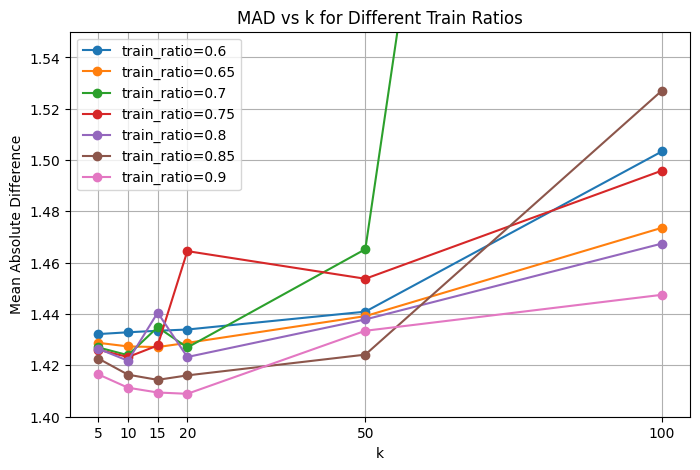

In [31]:

plt.figure()
for ratio in pivot_res.index:
    plt.plot(
        pivot_res.columns.astype(int),                  # the k values
        pivot_res.loc[ratio].values,                    # the MAD values
        marker='o',
        label=f"train_ratio={ratio}"
    )

plt.xlabel("k")
plt.ylabel("Mean Absolute Difference")
plt.title("MAD vs k for Different Train Ratios")
plt.xticks(pivot_res.columns.astype(int))
plt.legend()
plt.grid(True)
plt.ylim(1.4, 1.55)

plt.show()

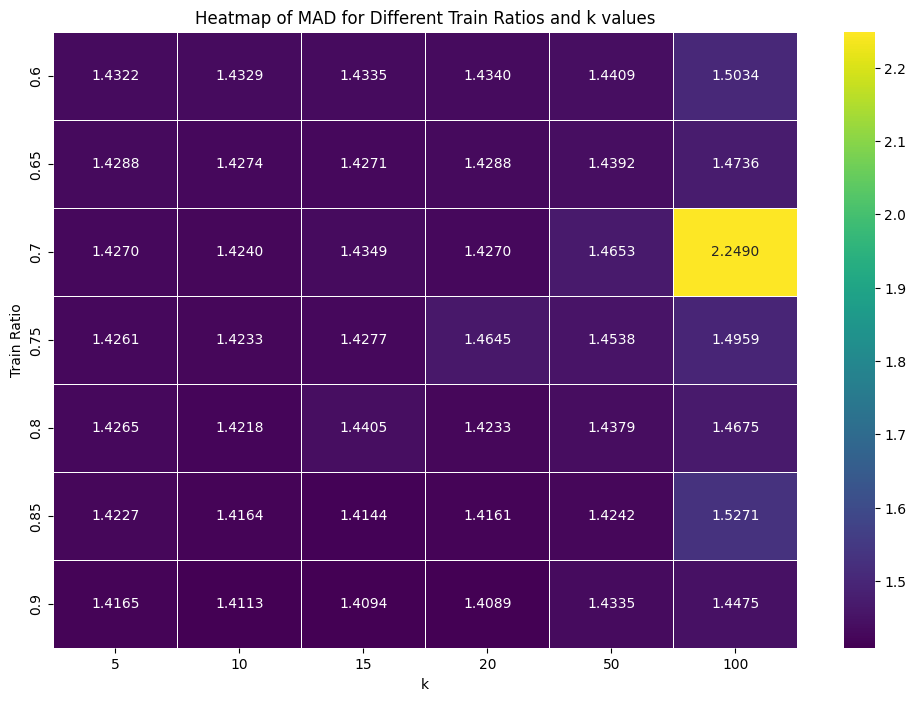

In [33]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_res, annot=True, fmt=".4f", cmap="viridis", linewidths=.5)
plt.title("Heatmap of MAD for Different Train Ratios and k values")
plt.xlabel("k")
plt.ylabel("Train Ratio")
plt.show()
